# Overview and main features

**1. Import packages**

**2. Load data and feature engineering:**
* Read csv files.
* Basic data cleanup (Replace/remove/extend non-plausible or missing values)
* Feature engineering:
    * Declare low cardinality integer features as categorical
    * Create N-grams of the categorical features (*N_GRAMS == [list of selected N-grams]*) and add (*N_GRAMS_EXT == True*) them to the original ones or threat them seperately for later preproccesing.
    * Digit decomposition
    * Physics-based feature engineering
    * Define categorical and numerical features
* Configure data spliting strategy for k-fold (*FOLD == k*) training. Spliting can be done with a stratified/grouped (*STRAT == True* / *GROUP == True*) or simple K-Fold splitter. As reference for the optional stratification either a calculated multilabel (based on selected features and/or labels) or simply the label can be used (*EXTENDED_STRAT == False*).

**3. Explore data:**
* List of dataset columns including data types and number of non-zero elements.
* Show number of unique elements of categorical features.
* Show probability distribution of numerical features.
* Numerical feature statistics
* Correlation analysis of numerical features
* Compare probabilty distribution of features and labels between train, validation and test sets (based on a single fold).

**4. Preprocess data:**
* The dataset includes 2 main types of data: numerical features and categorical features.
* Leakage-free data preprocessing pipeline. Selected preprocessing pipelines will be merged with a ColumnTransformer, possible options are:
    * MinMax/standard/robust scaling of numerical features
    * Logaritmic/square/cube/square root/cube root transformations of numerical features
    * KBins discretization of numerical features
    * Ordinal/onehot encoding of categorical features
    * Principal component analysis (PCA) of numerical features
    * Linear Discriminant Analysis (LDA) of numerical features
    * Multi statistical (mean/std/skew/median/min/max/frequency) target encoding for categorical and bucketized or continous (*BIN_NUM_STAT == None*) numerical features. The number of bins for discretization can be configured (*STAT_N_BINS*).
    * Preprocessed features can be passed into feature selection stages to remove highly correlated features (*THD_CORR_DROPPER != None*) and/or to extract most relevant features (*MAX_FEAT != None*). The correlation threshold and the maximum number of features can be configured (*THD_CORR_DROPPER/MAX_FEAT*).
* External dataset can be merged with the competition dataset for each fold seperately (*ADD_EXTERN_DATA == True*).

**5. Define model space for ML methods:**
* Definition of model space with a large number of possible ML methods:
    * Linear models: SGD
    * Support vector machine model: SVC
    * Ensemble models: RandomForest / GradientBoosting / AdaBoost / HistGradientBoosting / XGB / LGBM / CatBoost
    * Other models: KNeighbors
    * Neural network based models: RealMLP
* Definition of model parameter sets for both training and tuning interfaces.
* GPU acceleration can be activated (if supported by choosen ML method(s)) by *GPU_ACC*.

**6. Training:**
* Simple fitting or tuning (*TUNING == True*) of choosen models (*EST_IDS*) on whole trainval dataset with K-Fold method. Optionally, different seeds for the folds can be used (*MULTI_SEED == True*).
* Early stopping and the usage of category data type can be configured (*EST_IDS_W_EARLYSTOPPING/EST_IDS_W_CAT_FEAT*).
* Show single roc auc scores for each folds and average roc auc scores for each estimator over the folds during training.
* Stack (*STACKING == True*) or find individual weights for each estimator (*WEIGHTING == True*) .

**7. Evaluation:**
* Calculate roc auc scores for each estimators and mean roc auc score over all estimators based on accumulated Out-of-Fold (oof) samples.
* Show roc auc scores of subcategory subsets.
* Show worse roc auc scores of multicategory subsets.
* Show feature importances.

**8. Submission:**
* Calculate mean predictions and create submission.csv file.
* If more than 1 model have been choosen in EST_IDS (Ensemble solution) then the prediction will be an average of the predictions of the single models.

Note: A similar notebook have been linked as baseline for regression tasks.

In [1]:
## Import packages

# General purpose modules
import time
import warnings
from importlib.metadata import version
from itertools import combinations

# Data handling and visualization modules
import numpy as np
from scipy import stats
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns

# Skikit-learn preprocessing and evaluation modules
import sklearn
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, StratifiedGroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, KBinsDiscretizer, TargetEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils.multiclass import type_of_target

# Skikit-learn ML modules
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression

# Further ML modules
import xgboost as xgboost
import lightgbm as lightgbm
import catboost as catboost
import torch
import pytabkit
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier

# Show version numbers
print(f'Scikit-learn version: {sklearn.__version__}')
print(f'XGBoost version: {xgboost.__version__}')
print(f'LightGBM version: {lightgbm.__version__}')
print(f'CatBoost version: {catboost.__version__}')
print(f'PyTorch  version: {torch.__version__}')
print(f'PyTabKit  version: {version('pytabkit')}')

Scikit-learn version: 1.9.1
XGBoost version: 3.2.0
LightGBM version: 4.6.0
CatBoost version: 1.2.10
PyTorch  version: 2.10.0+cu128
PyTabKit  version: 1.7.3


# 1. Import packages

# 2. Load data and feature engineering

In [2]:
## Read csv files

trainval = pd.read_csv('/kaggle/input/competitions/playground-series-s6e10/train.csv')
extern_data = pd.read_csv('/kaggle/input/datasets/arseniyshutko/binary-aviation-satisfaction-129k/data.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e10/test.csv')

# Target column
target = 'satisfaction'
trainval[target] = trainval[target].astype('uint8')
extern_data[target] = extern_data[target].astype('uint8')

In [3]:
## Basic data cleanup: Replace/remove/extend non-plausible or missing values

DROP_NA = False # Drop samples including NaN values from the dataset

if DROP_NA:
    trainval = trainval.dropna().reset_index(drop=True)
    extern_data = extern_data.dropna().reset_index(drop=True)

In [4]:
## General feature engineering

# Declare low cardinality integer features as categorical
columns_to_cat = [col for col in trainval.columns if trainval[col].nunique() < 10 and col not in [target]]

for df in [trainval, extern_data, test]:
    df[columns_to_cat] = df[columns_to_cat].astype('object')
orig_cat_columns = [col for col in make_column_selector(dtype_include='object')(trainval) if col not in []]
orig_num_columns = [col for col in make_column_selector(dtype_include='number')(trainval) if col not in ['id', target]]
for df in [trainval, extern_data, test]:
    df[orig_cat_columns] = df[orig_cat_columns].astype('category')
    df[orig_num_columns] = df[orig_num_columns].astype('UInt16')

# Create n-grams from selected categorical columns  
N_GRAMS = [2]         # Choose n-grams to derive
cat_columns2ngrams = ['Class', 'Type of Travel', 'Gender', 'Customer Type', 'Age', 'Flight Distance', 'Departure Delay in Minutes'] # Selected categorical features for n-grams generation

def create_ngrams(df, n_grams=N_GRAMS):
    ngram_columns_dict = {} # Collect and concat the new columns to avoid memory fragmentation issues
    for n in n_grams:
        for ngram in combinations(cat_columns2ngrams, n):
            ngram_columns_dict[f'{n}gram_'+'_'.join(ngram)] = df[list(ngram)].astype(str).agg('_'.join, axis=1)
    ngram_columns_df = pd.DataFrame(ngram_columns_dict)
    updated_df = pd.concat([df, ngram_columns_df.astype('category')], axis=1)
    return updated_df
    
trainval = create_ngrams(trainval)
extern_data = create_ngrams(extern_data)
test = create_ngrams(test)

# Digit decomposition
DIG_DEC = True
columns_to_dig_dec = (orig_num_columns) if DIG_DEC else []

def digit_decomposition(df, num_features):
    df = df.copy()
    for c in num_features:
        if (trainval[c].dtype == 'UInt16' or trainval[c].dtype == 'category'):
            LD = 0
        else:
            LD = -1
        for k in range(LD,6):
            digits = (df[c].astype('float').fillna(0) // (10**k) % 10).astype('category')
            if digits.nunique() > 1 and df[c].astype('float').max() >= 10:
                df[f"{c}_digit{k+1}"] = digits
    return df

trainval = digit_decomposition(trainval, columns_to_dig_dec)
extern_data = digit_decomposition(extern_data, columns_to_dig_dec)
test = digit_decomposition(test, columns_to_dig_dec)

In [5]:
## Handcrafted feature engineering

# Physics-based feature engineering
def feature_engineering(df):
    df = df.copy()
    eps = 1e-6
    return df

trainval = feature_engineering(trainval)
extern_data = feature_engineering(extern_data)
test = feature_engineering(test)

In [6]:
## Define features

# Define categorical features
cat_columns = [col for col in make_column_selector(dtype_include='category')(trainval) if col not in []]
ngrams_columns = make_column_selector(pattern='gram_')(trainval)
digit_columns = make_column_selector(pattern='_digit')(trainval)

print(f'Number of original categorical features: {len(orig_cat_columns)}')
print(f'Number of N-Grams features: {len(ngrams_columns)}')
print(f'Number of digit features: {len(digit_columns)}')
print(f'Number of extended categorical features: {len(cat_columns)}')

# Define numerical features
num_columns = [col for col in make_column_selector(dtype_include=['number'])(trainval) if col not in ['id', target]]
float_columns = [col for col in make_column_selector(dtype_include=['float'])(trainval) if col not in ['id', target]]

print(f'Number of original numerical features: {len(orig_num_columns)}')
print(f'Number of extended numerical features: {len(num_columns)}')
print(f'Number of float features: {len(float_columns)}')

Number of original categorical features: 17
Number of N-Grams features: 21
Number of digit features: 12
Number of extended categorical features: 50
Number of original numerical features: 4
Number of extended numerical features: 4
Number of float features: 0


In [7]:
## Configure data spliting strategy for k-fold training

STRAT = False             # Use stratification for data spliting
EXTENDED_STRAT = False    # Stratification is based on multiple features
GROUP = False             # Use grouping for data spliting
FOLDS = 5                 # Number of folds for k-fold training

# Create multilabel column for evaluation purposes
multicat_encoder = LabelEncoder()
multicat_eval = ['Class', 'Type of Travel', 'Gender', 'Customer Type', 'Age']
trainval['multicat'] = multicat_encoder.fit_transform(trainval[multicat_eval].astype(str).agg('_'.join, axis=1)).astype('uint16')

# Determine stratification bins
strat_bin_encoder = LabelEncoder()
strat_cols = ['Class', 'Type of Travel', 'Gender', 'Customer Type', 'Age'] + [target]
trainval['strat_bin'] = strat_bin_encoder.fit_transform(trainval[strat_cols].astype(str).agg('_'.join, axis=1)).astype('uint16')

# Merge rare multicats into one category
rare_strat_bins = trainval['strat_bin'].value_counts()[trainval['strat_bin'].value_counts() < FOLDS].index.tolist()
if len(rare_strat_bins)>0:
    trainval['strat_bin'] = trainval['strat_bin'].replace(rare_strat_bins, rare_strat_bins[0])

# Experimental data spliting to check spliting quality
skf = ((StratifiedGroupKFold if GROUP else StratifiedKFold) if STRAT else (GroupKFold if GROUP else KFold))(
    n_splits=FOLDS, shuffle=True, random_state=42)
strat_col = 'strat_bin' if EXTENDED_STRAT else target
group_col = 'id'
train_idx, val_idx = next(skf.split(trainval, trainval[strat_col], trainval[group_col]))
train = trainval.iloc[train_idx].reset_index(drop=True)
val = trainval.iloc[val_idx].reset_index(drop=True)

# Verify dataset sizes of first fold
print(f'Total rows:   {len(trainval)}')
print(f'Dev train:    {len(train)} ({len(train)/len(trainval):.2%})')
print(f'Dev valid:    {len(val)} ({len(val)/len(trainval):.2%})')
print('-'*80, end='\n\n')

# Size of stratification bins
print(trainval['strat_bin'].value_counts().tail())
print(f'Number of unique elements in strat_bin column: {len(trainval['strat_bin'].unique())}')
print('-'*80, end='\n\n')
print(trainval['multicat'].value_counts().tail())
print(f'Number of unique elements in multicat column: {len(trainval['multicat'].unique())}')

Total rows:   699635
Dev train:    559708 (80.00%)
Dev valid:    139927 (20.00%)
--------------------------------------------------------------------------------

strat_bin
708     5
981     5
1100    5
1243    5
983     5
Name: count, dtype: int64
Number of unique elements in strat_bin column: 1826
--------------------------------------------------------------------------------

multicat
896     1
581     1
1102    1
470     1
898     1
Name: count, dtype: int64
Number of unique elements in multicat column: 1230


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


# 3. Explore data

In [8]:
## Explore train dataset

print('List of dataset columns including data types and number of non-zero elements: ', end='\n\n')
train.info()
print('-'*80, end='\n\n')
print('List of dataset columns including NaN values:')
nan_cols = [col for col in train.columns if pd.isna(train[col]).any()]
if nan_cols:
    for col in nan_cols: print(col)
else:
    print('No missing values found')

List of dataset columns including data types and number of non-zero elements: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 559708 entries, 0 to 559707
Data columns (total 58 columns):
 #   Column                                            Non-Null Count   Dtype   
---  ------                                            --------------   -----   
 0   id                                                559708 non-null  int64   
 1   Age                                               559708 non-null  UInt16  
 2   Flight Distance                                   559708 non-null  UInt16  
 3   Inflight wifi service                             559708 non-null  category
 4   Departure/Arrival time convenient                 559708 non-null  category
 5   Ease of Online booking                            559708 non-null  category
 6   Gate location                                     559708 non-null  category
 7   Food and drink                                    559708 non-null  category

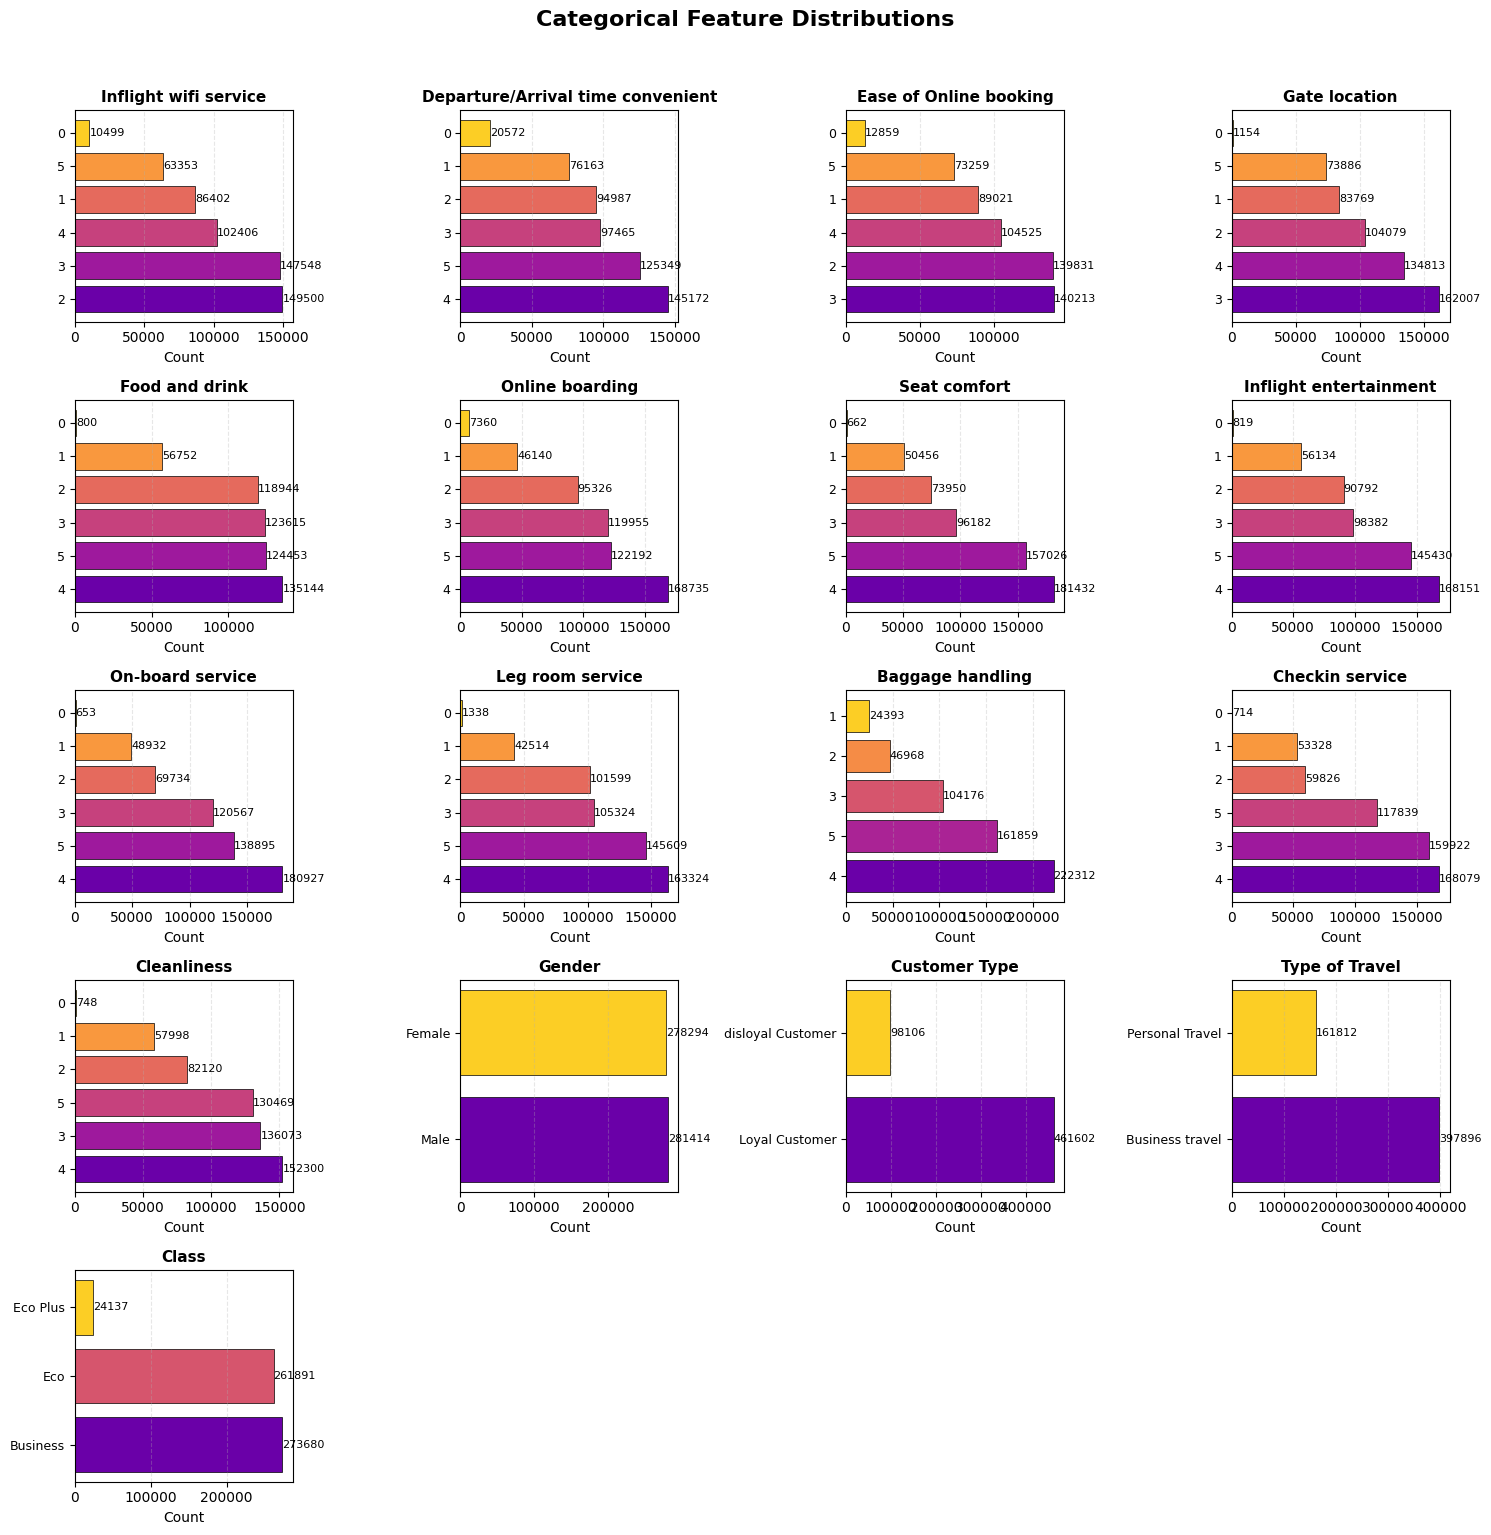

In [9]:
## Explore categorical features

SHOW_ORIG_CATS = True     # Show original or engineered categorical features

n_diags = len(orig_cat_columns if SHOW_ORIG_CATS else cat_columns)
n_cols = min(4, n_diags)
n_rows = (n_diags + n_cols - 1) // n_cols
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes1 = axes1.flatten()
detailed_cols = []

for idx, cat in enumerate(orig_cat_columns if SHOW_ORIG_CATS else cat_columns):
    value_counts = train[cat].value_counts()
    if len(value_counts) > 10:
        value_counts = value_counts.head(10)
        title_suffix = ' (Top 10)'
        detailed_cols.append(cat)
    else:
        title_suffix = ''
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(value_counts)))
    bars = axes1[idx].barh(range(len(value_counts)), value_counts.values, color=colors, edgecolor='black', linewidth=0.5)
    axes1[idx].set_yticks(range(len(value_counts)))
    axes1[idx].set_yticklabels(value_counts.index, fontsize=9)
    axes1[idx].set_xlabel('Count', fontsize=10)
    axes1[idx].set_title(f'{cat}{title_suffix}', fontsize=11, fontweight='bold')
    
    for bar, count in zip(bars, value_counts.values):
        axes1[idx].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{count}', va='center', fontsize=8)
    axes1[idx].grid(axis='x', alpha=0.3, linestyle='--')

for idx in range(n_diags, len(axes1)):
    axes1[idx].axis('off')
plt.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Detailed categorical feature statistics for high-cardinality categories
for cat in detailed_cols:
    print(f'\n{cat}:')
    print(f'  Unique values: {train[cat].nunique()}')
    print(f'  Most common: {train[cat].value_counts().index[0]} ({train[cat].value_counts().values[0]:,} samples)')
    print(f'  Least common: {train[cat].value_counts().index[-1]} ({train[cat].value_counts().values[-1]:,} samples)')

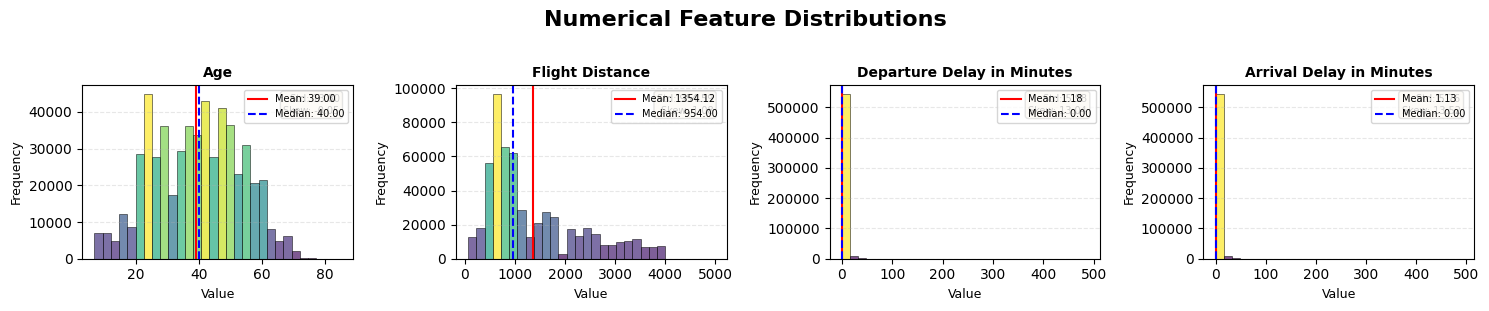


Numerical Features Summary Statistics:


,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,559708.0,559708.0,559708.0,559477.0
mean,39.0,1354.12,1.18,1.13
std,13.8,954.59,5.98,5.76
min,7.0,67.0,0.0,0.0
25%,27.0,631.0,0.0,0.0
50%,40.0,954.0,0.0,0.0
75%,50.0,1814.0,0.0,0.0
max,85.0,4983.0,489.0,491.0


In [10]:
## Explore numerical features

SHOW_ORIG_NUMS = True     # Show original or engineered categorical features

n_diags = len(orig_num_columns if SHOW_ORIG_NUMS else num_columns)
n_cols = min(4, n_diags)
n_rows = (n_diags + n_cols - 1) // n_cols
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes2 = axes2.flatten()

for idx, num_col in enumerate(orig_num_columns if SHOW_ORIG_NUMS else num_columns):
    data = train[num_col].dropna()
    n_bins = min(30, len(data.unique()))
    counts, bins, patches = axes2[idx].hist(data, bins=n_bins, edgecolor='black', linewidth=0.5, alpha=0.7)
    norm = plt.Normalize(counts.min(), counts.max())
    for patch, count in zip(patches, counts):
        patch.set_facecolor(plt.cm.viridis(norm(count)))
    
    mean_val = data.mean()
    median_val = data.median()
    axes2[idx].axvline(mean_val, color='red', linestyle='-', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    axes2[idx].axvline(median_val, color='blue', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.2f}')
    
    axes2[idx].set_xlabel('Value', fontsize=9)
    axes2[idx].set_ylabel('Frequency', fontsize=9)
    axes2[idx].set_title(f'{num_col}', fontsize=10, fontweight='bold')
    axes2[idx].legend(fontsize=7, loc='upper right')
    axes2[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    stats_text = f'Std: {data.std():.2f}\nSkew: {data.skew():.2f}'
    axes2[idx].text(0.95, 0.95, stats_text, transform=axes2[idx].transAxes, fontsize=7, verticalalignment='top',
                   horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

for idx in range(n_diags, len(axes2)):
    axes2[idx].axis('off')
plt.suptitle('Numerical Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Numerical feature statistics
print('\nNumerical Features Summary Statistics:')
pd.set_option('display.max_columns', None)
train[num_columns].describe(include='all').round(2)

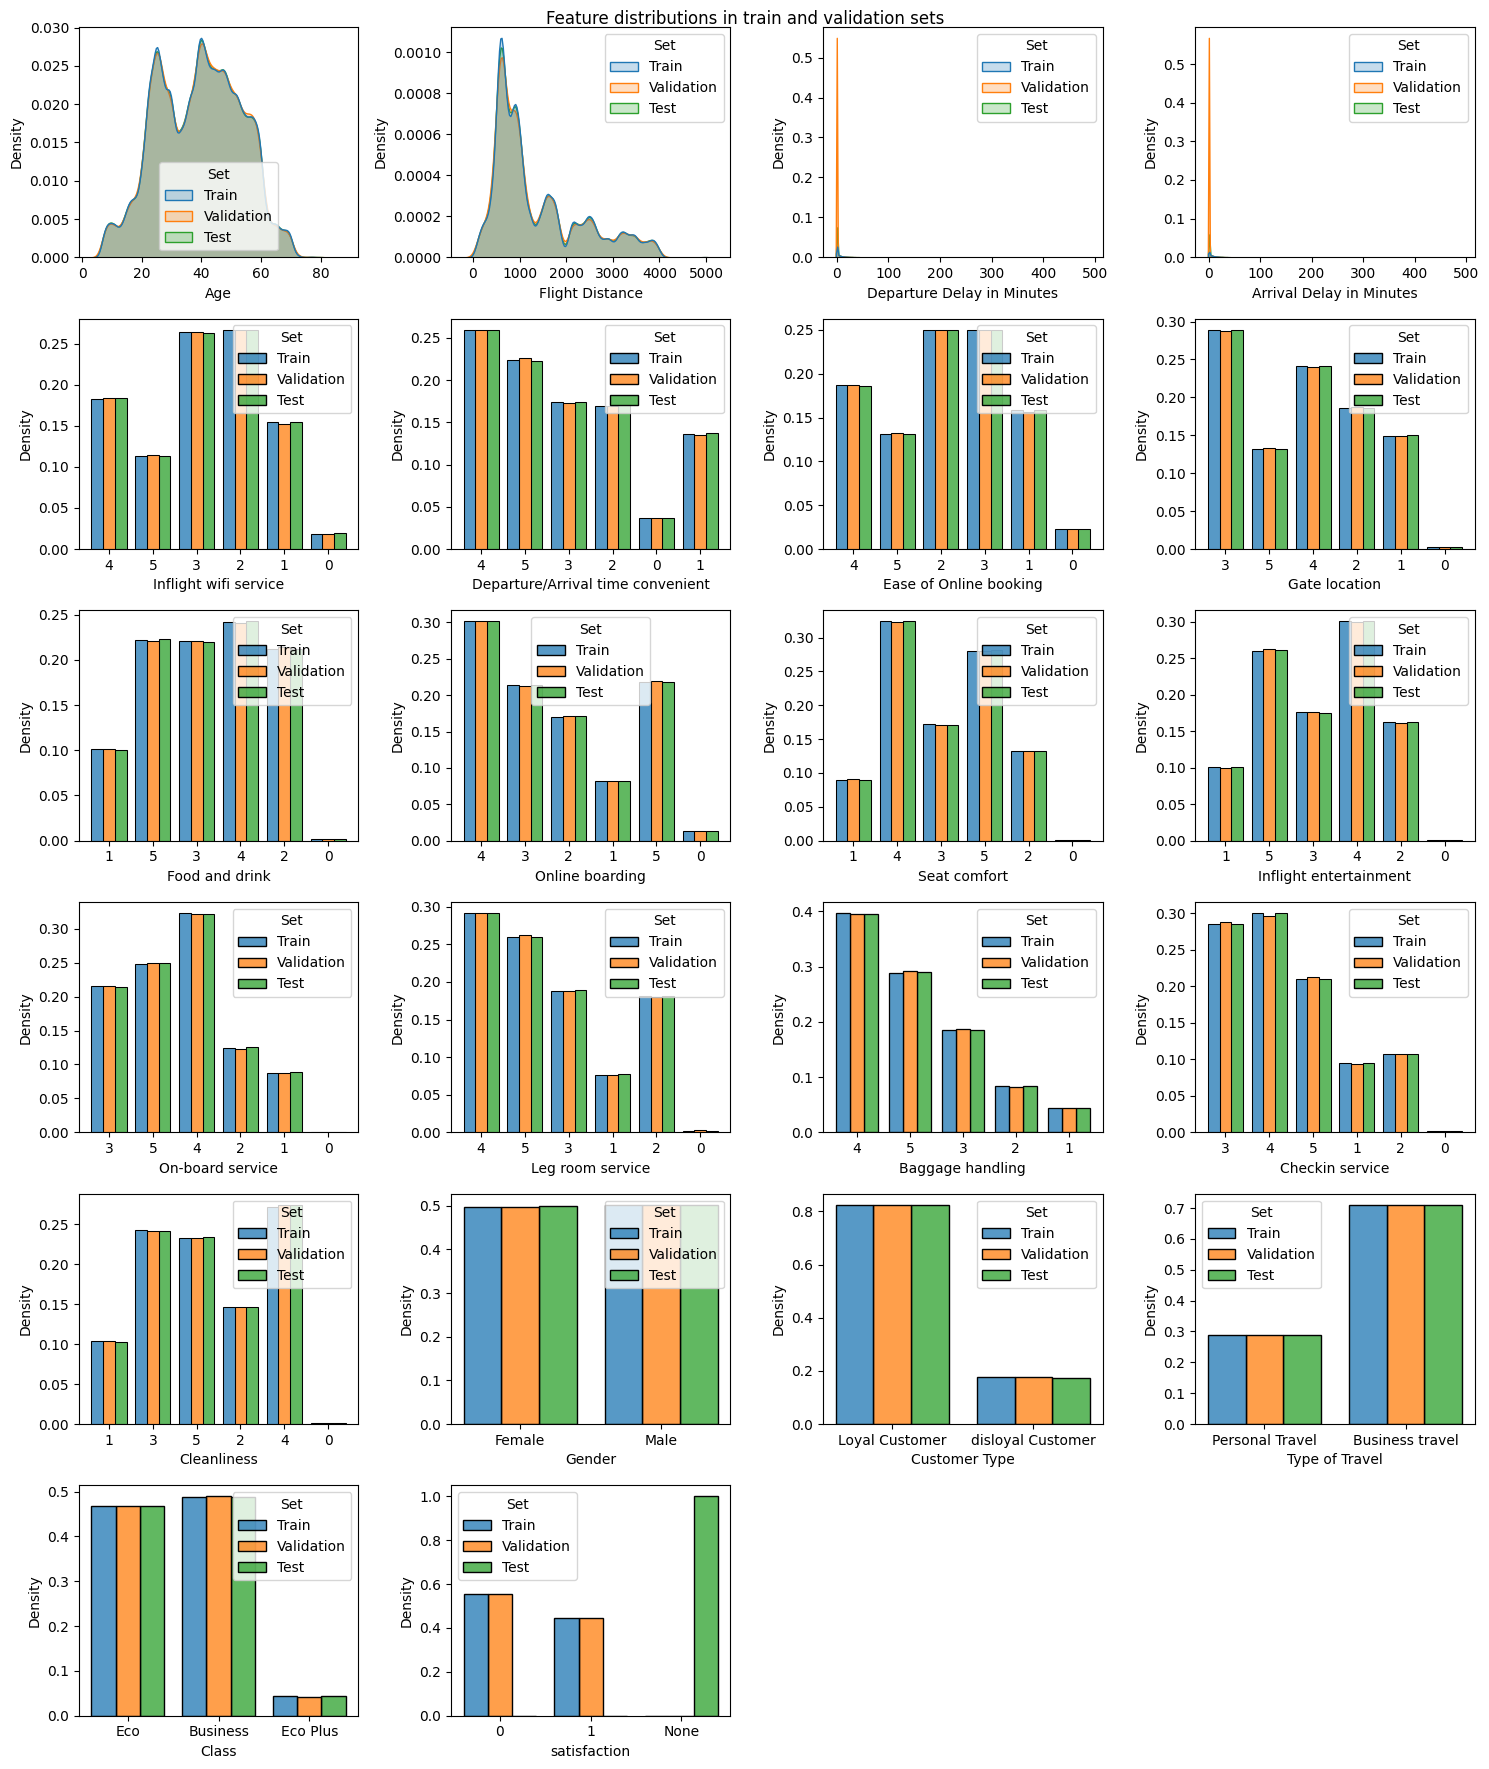

In [11]:
## Compare probabilty distribution of features and labels between train, validation and test sets (based on a single fold)

# Create a dataframe with assigned sources (train/validation/test)
df_plot = pd.concat([train[orig_num_columns+orig_cat_columns].assign(Set='Train'), val[orig_num_columns+orig_cat_columns].assign(Set='Validation'),
                     test[orig_num_columns+orig_cat_columns].assign(Set='Test')])
df_plot.insert(3, value=pd.concat([train[target], val[target], pd.Series([None] * len(test), name=target)]), column=target)
df_plot[orig_cat_columns + [target]] = df_plot[orig_cat_columns + [target]].astype('str')
df_plot.reset_index(drop=True, inplace=True)
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn') # Suppress the specific FutureWarning

# Plot probabilty distribution of features
n_diags = len(orig_num_columns+orig_cat_columns+[target])
n_cols = min(4, n_diags)
n_rows = (n_diags + n_cols - 1) // n_cols
fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
fig3.suptitle('Feature distributions in train and validation sets')
axes3 = axes3.flatten()
for i, col in enumerate(orig_num_columns):
    sns.kdeplot(data=df_plot, x=col, ax=axes3[i], hue='Set', common_norm=False, fill=True)
for j, col in enumerate(orig_cat_columns + [target]):
    sns.histplot(data=df_plot, x=col, ax=axes3[i+1+j], hue='Set', bins=len(df_plot[col].unique()),
                 stat='density', discrete=True, multiple='dodge', common_norm=False, shrink=.8)

for idx in range(n_diags, len(axes3)):
    axes3[idx].axis('off')
plt.tight_layout()
plt.show()
del df_plot

# 4. Preprocess data

In [12]:
# Leakage-safe target-statistics encoder

class MultiStatTargetEncoder(BaseEstimator, TransformerMixin):
    """
    Scikit-learn compatible target encoder supporting:
    - Multi-statistic calculations: mean, median, std, min, max, skew, frequency
    - Multi-scale smoothing (e.g., m=[1.0, 10.0, 50.0])
    - Out-of-Fold (OOF) target encoding to prevent leakage

    Parameters
    ----------
    stats : list of str, default=['mean', 'median', 'std', 'min', 'max', 'skew', 'frequency']
        Statistics to compute. Allowed: 'mean', 'median', 'std', 'min', 'max', 'skew', 'frequency'.
    smooth : float, list of float, or dict, default=10.0
        Smoothing parameter(s) representing pseudo-counts of global prior.
    cv : int, default=5
        Number of folds for Out-of-Fold (OOF) training. Set to None or 1 to disable.
    noise_level : float, default=0.0
        Additive Gaussian noise proportion applied during fit_transform (e.g. 0.01 = 1%).
    fill_strategy : str, default='global'
        Strategy for missing/unseen categories ('global' or 'nan').
    min_samples_skew : int, default=5
        Minimum category count required to compute skew.
    """

    ALLOWED_STATS = {'mean', 'median', 'std', 'min', 'max', 'skew', 'frequency'}

    def __init__(self, stats=['mean', 'median', 'std', 'min', 'max', 'skew', 'frequency'], smooth=10.0,
                 cv=5, noise_level=0.0, shuffle=True, random_state=42, fill_strategy='global', min_samples_skew=5):
        self.stats = stats
        self.smooth = smooth
        self.cv = cv
        self.noise_level = noise_level
        self.shuffle = shuffle
        self.random_state = random_state
        self.fill_strategy = fill_strategy
        self.min_samples_skew = min_samples_skew

    def set_output(self, *, transform='panda'):
        self._output_transform = transform
        return self

    def _format_output(self, df):
        output_config = getattr(self, '_output_transform', 'default')
        if output_config == 'default':
            return df.to_numpy()
        return df

    def _parse_m_values(self):
        """Parses smooth into a dictionary mapping each statistic to a list of (m_val, suffix)."""
        m_config = {}
        for stat_name in self.ALLOWED_STATS:
            if stat_name == 'frequency':
                continue

            if isinstance(self.smooth, dict):
                raw_m = self.smooth.get(stat_name, 10.0)
            else:
                raw_m = self.smooth

            if isinstance(raw_m, (list, tuple, np.ndarray)):
                m_config[stat_name] = [(float(m), f"_m{m}") for m in raw_m]
            else:
                m_config[stat_name] = [(float(raw_m), "")]
        return m_config

    def _compute_stats(self, X_df, y_ser, m_config):
        total_samples = len(y_ser)
        global_stats = {'mean': float(y_ser.mean()),
                        'median': float(y_ser.median()),
                        'std': float(y_ser.std(ddof=0)) if total_samples > 1 else 0.0,
                        'var': float(y_ser.var(ddof=0)) if total_samples > 1 else 0.0,
                        'min': float(y_ser.min()),
                        'max': float(y_ser.max()),
                        'skew': float(stats.skew(y_ser, nan_policy='omit')) if total_samples > 2 else 0.0,
                        'frequency': 0.0}

        encodings = {}
        for col in self.columns_:
            col_data = pd.DataFrame({'cat': X_df[col], 'target': y_ser})
            grouped = col_data.groupby('cat', observed=False)['target']
            raw_counts = grouped.count()
            mapping_df = pd.DataFrame(index=grouped.indices.keys())

            if 'frequency' in self.stats:
                mapping_df[f'{col}_te_frequency'] = raw_counts / total_samples
                
            if 'mean' in self.stats:
                cat_mean = grouped.mean()
                for m, suffix in m_config['mean']:
                    col_name = f'{col}_te_mean{suffix}'
                    mapping_df[col_name] = (raw_counts * cat_mean + m * global_stats['mean']) / (raw_counts + m) if m > 0 else cat_mean
                    
            if 'median' in self.stats:
                cat_median = grouped.median()
                for m, suffix in m_config['median']:
                    col_name = f'{col}_te_median{suffix}'
                    mapping_df[col_name] = (raw_counts * cat_median + m * global_stats['median']) / (raw_counts + m) if m > 0 else cat_median

            if 'std' in self.stats:
                cat_var = grouped.var(ddof=0).fillna(0.0)
                for m, suffix in m_config['std']:
                    col_name = f'{col}_te_std{suffix}'
                    if m > 0:
                        smoothed_var = (raw_counts * cat_var + m * global_stats['var']) / (raw_counts + m)
                        mapping_df[col_name] = np.sqrt(smoothed_var)
                    else:
                        mapping_df[col_name] = np.sqrt(cat_var)

            if 'min' in self.stats:
                cat_min = grouped.min()
                for m, suffix in m_config['min']:
                    col_name = f'{col}_te_min{suffix}'
                    mapping_df[col_name] = (raw_counts * cat_min + m * global_stats['min']) / (raw_counts + m) if m > 0 else cat_min

            if 'max' in self.stats:
                cat_max = grouped.max()
                for m, suffix in m_config['max']:
                    col_name = f'{col}_te_max{suffix}'
                    mapping_df[col_name] = (raw_counts * cat_max + m * global_stats['max']) / (raw_counts + m) if m > 0 else cat_max

            if 'skew' in self.stats:
                def _safe_skew(s):
                    if len(s) >= self.min_samples_skew:
                        val = stats.skew(s, nan_policy='omit')
                        return 0.0 if np.isnan(val) else val
                    return global_stats['skew']

                cat_skew = grouped.apply(_safe_skew)
                for m, suffix in m_config['skew']:
                    col_name = f'{col}_te_skew{suffix}'
                    mapping_df[col_name] = (raw_counts * cat_skew + m * global_stats['skew']) / (raw_counts + m) if m > 0 else cat_skew

            encodings[col] = mapping_df
        return encodings, global_stats

    def _transform_subset(self, X_df, encodings, global_stats, m_config):
        encoded_dfs = []
        for col in self.columns_:
            mapping = encodings[col]
            mapped = X_df[[col]].merge(mapping, how='left', left_on=col, right_index=True)
            mapped = mapped.drop(columns=[col])

            if self.fill_strategy == 'global':
                for stat_name in self.stats:
                    if stat_name == 'frequency':
                        mapped[f'{col}_te_frequency'] = mapped[f'{col}_te_frequency'].fillna(global_stats['frequency'])
                    else:
                        for _, suffix in m_config[stat_name]:
                            target_col = f'{col}_te_{stat_name}{suffix}'
                            mapped[target_col] = mapped[target_col].fillna(global_stats[stat_name])

            encoded_dfs.append(mapped)

        encoded_result = pd.concat(encoded_dfs, axis=1)
        remaining_cols = [c for c in X_df.columns if c not in self.columns_]
        return pd.concat([X_df[remaining_cols], encoded_result], axis=1)

    def fit(self, X, y):
        invalid = set(self.stats) - self.ALLOWED_STATS
        if invalid:
            raise ValueError(f"Unsupported statistics requested: {invalid}. Allowed: {self.ALLOWED_STATS}")

        X_df = self._check_input(X)
        y_ser = pd.Series(y, index=X_df.index, name="target")
        self.columns_ = list(X_df.columns)
        self.m_config_ = self._parse_m_values()

        self.encodings_, self.global_stats_ = self._compute_stats(X_df, y_ser, self.m_config_)

        # Derive feature names out
        dummy_transformed = self._transform_subset(X_df.iloc[:1], self.encodings_, self.global_stats_, self.m_config_)
        self.feature_names_out_ = np.array(dummy_transformed.columns, dtype=object)

        return self

    def transform(self, X):
        X_df = self._check_input(X)
        transformed_df = self._transform_subset(X_df, self.encodings_, self.global_stats_, self.m_config_)
        return self._format_output(transformed_df)

    def fit_transform(self, X, y):
        invalid = set(self.stats) - self.ALLOWED_STATS
        if invalid:
            raise ValueError(f"Unsupported statistics requested: {invalid}. Allowed: {self.ALLOWED_STATS}")

        X_df = self._check_input(X)
        y_ser = pd.Series(y, index=X_df.index, name="target")
        self.columns_ = list(X_df.columns)
        self.m_config_ = self._parse_m_values()

        # 1. Fit on full data for downstream inference (.transform)
        self.encodings_, self.global_stats_ = self._compute_stats(X_df, y_ser, self.m_config_)
        dummy_transformed = self._transform_subset(X_df.iloc[:1], self.encodings_, self.global_stats_, self.m_config_)
        self.feature_names_out_ = np.array(dummy_transformed.columns, dtype=object)

        if not self.cv or self.cv <= 1:
            return self._format_output(self._transform_subset(X_df, self.encodings_, self.global_stats_, self.m_config_))

        # 2. Out-of-Fold (OOF) training transform
        if type_of_target(y) in ('binary', 'multiclass'):
            splitter = StratifiedKFold(n_splits=self.cv, shuffle=self.shuffle, random_state=self.random_state)
            splits = splitter.split(X_df, y_ser)
        else:
            splitter = KFold(n_splits=self.cv, shuffle=self.shuffle, random_state=self.random_state)
            splits = splitter.split(X_df)

        oof_parts = []
        rng = np.random.default_rng(self.random_state)

        for train_idx, val_idx in splits:
            X_tr, y_tr = X_df.iloc[train_idx], y_ser.iloc[train_idx]
            X_val = X_df.iloc[val_idx]

            fold_encodings, fold_global_stats = self._compute_stats(X_tr, y_tr, self.m_config_)
            val_encoded = self._transform_subset(X_val, fold_encodings, fold_global_stats, self.m_config_)
            oof_parts.append(val_encoded)

        oof_df = pd.concat(oof_parts, axis=0).loc[X_df.index]

        # 3. Optional Gaussian noise
        if self.noise_level > 0.0:
            for col in self.columns_:
                for stat_name in self.stats:
                    if stat_name != 'frequency':
                        for _, suffix in self.m_config_[stat_name]:
                            target_col = f'{col}_te_{stat_name}{suffix}'
                            noise = rng.normal(loc=0.0, scale=self.noise_level * self.global_stats_['std'], size=len(oof_df))
                            oof_df[target_col] += noise

        return self._format_output(oof_df)

    def get_feature_names_out(self, input_features=None):
        if not hasattr(self, 'feature_names_out_'):
            raise ValueError("Transformer has not been fitted yet.")
        return self.feature_names_out_

    def _check_input(self, X):
        if isinstance(X, pd.DataFrame):
            return X.copy()
        elif isinstance(X, np.ndarray):
            return pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
        else:
            return pd.DataFrame(X)

In [13]:
## Leakage-safe feature selection class based on feature correlation

class CorrelationDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold):
        self.threshold = threshold
        self.n_features_in_ = None
        self.n_features_out_ = None

    def fit(self, X, y=None, verbose=True):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop_ = [col for col in upper.columns if any(upper[col] >= self.threshold)]
        self.n_features_in_ = len(X.columns)
        self.n_features_out_ = self.n_features_in_ - len(self.to_drop_)
        if verbose:
            print(f'Number of features before feature selection: {self.n_features_in_}')
            print(f'Number of features after applying correlation dropper: {self.n_features_out_}')
        return self

    def transform(self, X):
        return X.drop(columns=[c for c in self.to_drop_ if c in X.columns])

    def get_feature_names_out(self, input_features=None):
        return np.array([c for c in input_features if c not in self.to_drop_])

In [14]:
## Feature selection wrapper based on XGBoost/CatBoost feature importances

def create_feature_selector(max_features):
    # Define base model for feature selection
    xgbr_fs = xgboost.XGBClassifier(device ='cuda' if GPU_ACC else 'cpu', random_state=42, enable_categorical=True, verbosity=0)
    catc_fs = catboost.CatBoostClassifier(auto_class_weights='Balanced',random_state=42, task_type='GPU' if GPU_ACC else 'CPU', verbose=False)
    model_fs = SelectFromModel(xgbr_fs, max_features=max_features, threshold=1e-6, prefit=False).set_output(transform='pandas')
    return model_fs

In [15]:
##  Preprocessor pipeline creating function

def create_preprocessor(est_id):
    # Pipelines for numerical features
    num_imputer = SimpleImputer(strategy='median', add_indicator=True) # SimpleImputer(strategy='median', add_indicator=True) / 'passthrough'
    prescaler = MinMaxScaler(feature_range=(0.001, 1), clip=True)
    scaler = MinMaxScaler() # MinMaxScaler() / StandardScaler() / RobustScaler() / 'passthrough'
    eps = 1e-6
    
    scaled_pipeline = Pipeline([('imputer', num_imputer),
                                ('scaling', scaler)])
    nonlinear_transformers = ColumnTransformer([('scaled', 'passthrough', num_columns),
                                                ('log', FunctionTransformer(func=lambda x: np.log(np.abs(x)+eps), feature_names_out='one-to-one'), num_columns),
                                                ('square', FunctionTransformer(func=np.square, feature_names_out='one-to-one'), num_columns),
                                                ('cube', FunctionTransformer(func=lambda x: np.power(x, 3), feature_names_out='one-to-one'), num_columns),
                                                ('sqrt', FunctionTransformer(func=lambda x: np.sqrt(np.abs(x)+eps), feature_names_out='one-to-one'), num_columns),
                                                ('cbrt', FunctionTransformer(func=lambda x: np.cbrt(x), feature_names_out='one-to-one'), num_columns)
                                                ])
    nonlinear_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                   ('prescaling', prescaler),
                                   ('nonlin', nonlinear_transformers),
                                   ('scaling', scaler)])

    # Pipelines for PCA/LDA on non-linear transformations of numerical features
    pca_pipeline = Pipeline([('nonlin', nonlinear_pipeline),
                             ('pca', PCA(n_components=10, random_state=42))])
    lda_pipeline = Pipeline([('nonlin', nonlinear_pipeline),
                             ('lda', LinearDiscriminantAnalysis(n_components=1))])

    # Pipelines for categorical features
    cat_imputer = SimpleImputer(strategy='constant', fill_value='NA') # SimpleImputer(strategy='most_frequent')
    cat_casting = FunctionTransformer(lambda x: x.astype('category' if est_id in EST_IDS_W_CAT_FEAT else 'int16'), feature_names_out='one-to-one')
    
    ordinal_pipeline = Pipeline([('imputer', cat_imputer),
                                 ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', encoded_missing_value=-2,
                                                            unknown_value=-1).set_output(transform='pandas')),
                                 ('ordinal_cast', cat_casting)])
    onehot_pipeline = Pipeline([('imputer', cat_imputer),
                                ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
                                ('onehot_cast', cat_casting)])
    kbins_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                               ('kbins', KBinsDiscretizer(n_bins=STAT_N_BINS, strategy='uniform', encode='ordinal', random_state=42)),
                               ('kbins_cast', cat_casting)])
    kmeans_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                                ('scaler', scaler),
                                ('kmeans', KMeans(n_clusters=9, random_state=42)),
                                ('kmeans_cast', cat_casting)])
    
    # Pipelines for statistical features
    te_num_pipeline = Pipeline([('bin', kbins_pipeline if BIN_NUM_STAT else 'passthrough'),
                                ('te_num', MultiStatTargetEncoder(stats=['mean'], smooth=[0,74,89]))])
    te_cat_pipeline = Pipeline([('te_cat', MultiStatTargetEncoder(stats=['mean', 'frequency'], smooth=[0]))])
       
    # Preprocessor pipeline wo feature selection
    preprocessing = ColumnTransformer([## Numerical transformations
                                       ('scaled', scaled_pipeline, num_columns),
                                       #('nonlin', nonlinear_pipeline, num_columns),
                                       #('pca', pca_pipeline, num_columns),
                                       #('lda', lda_pipeline, num_columns),

                                       ## Categorical encoding
                                       ('ordinal', ordinal_pipeline, cat_columns),
                                       #('onehot', onehot_pipeline, cat_columns),
                                       #('cluster', kbins_pipeline, float_columns),
                                       #('kmeans', kmeans_pipeline, num_columns),
        
                                       ## Statistical transformers
                                       ('te_num_stats', te_num_pipeline, num_columns),
                                       ('te_cat_stats', te_cat_pipeline, ngrams_columns),
                                       ]).set_output(transform='pandas')

    # Preprocessor pipeline including feature selection
    preprocessor_pipeline = Pipeline([('preprocessing', preprocessing),
                                      ('corr_dropper', CorrelationDropper(THD_CORR_DROPPER) if THD_CORR_DROPPER else 'passthrough'),
                                      ('feat_selector', create_feature_selector(MAX_FEAT) if MAX_FEAT else 'passthrough'),
                                     ])
    return preprocessor_pipeline

In [16]:
## Merge data sources

def merge_extern_data(df, external):
    df_columns = [col for col in df.columns if col not in ['id', 'multicat', 'strat_bin']]
    df_merged = pd.concat([df[df_columns], external[df_columns]], ignore_index=True).reset_index(names='id')
    df_merged = df_merged.drop_duplicates()
    return df_merged

# 5. Define model space for ML methods

In [17]:
## Machine learning models and their hyperparameter search space

GPU_ACC = torch.cuda.is_available()

# Models
svc = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
rfc = RandomForestClassifier(class_weight='balanced', random_state=42) #ExtraTreesClassifier
kneigh = KNeighborsClassifier()
gbc = GradientBoostingClassifier(random_state=42)
xgb = xgboost.XGBClassifier(objective='binary:logistic', eval_metric='auc', enable_categorical=True,
                            device='cuda' if GPU_ACC else 'cpu', random_state=42)
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced', random_state=42), random_state=42)
hgbc = HistGradientBoostingClassifier(scoring='roc_auc', class_weight='balanced', random_state=42)
lgbm = lightgbm.LGBMClassifier(objective='binary', metric='auc', class_weight='balanced',
                               device ='gpu' if GPU_ACC else 'cpu', verbosity=-1, n_jobs=-1, random_state=42)
catc = catboost.CatBoostClassifier(loss_function='Logloss', eval_metric='AUC', auto_class_weights='Balanced',
                                   task_type='GPU' if GPU_ACC else 'CPU', verbose=False, random_state=3)
sgdc = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=42)
rmlp = RealMLP_TD_Classifier(val_metric_name='1-auc_ovr', device='cuda' if GPU_ACC else 'cpu',
                             random_state=42, verbosity=2)

# Model space
EstimatorStr = {1: 'svc', 2: 'rfc', 3: 'kneigh', 4: 'gbc', 5: 'xgb', 6: 'ada',
                7: 'hgbc', 8: 'lgbm', 9: 'catc', 10: 'sgdc', 11: 'rmlp'}
EstimatorMdl = {1: svc, 2: rfc, 3: kneigh, 4: gbc, 5: xgb, 6: ada, 7: hgbc, 8: lgbm, 9: catc, 10: sgdc, 11: rmlp}

In [18]:
## Helping function to create parameter grids

def make_param(param_dict, model='est'):
    for elem in param_dict.copy():
        if elem == 'n_components':
            param_dict['pre__preprocessing__pca'+'__'+elem] = param_dict.pop(elem)
        if elem == 'smooth_num':
            param_dict['pre__preprocessing__te_num_stats__te_num__smooth'] = param_dict.pop(elem)
        else:
            param_dict[model+'__'+elem] = param_dict.pop(elem)
    return param_dict

def generate_log_uniform_int_list(samples=9, low=0, high=10000, min_len=1, max_len=4, random_state=None):
    """Generates a list of sorted list of unique integers starting from 0, sampled log-uniformly"""
    list_of_lists = []
    for _ in range(samples):
        rng = np.random.default_rng(random_state)
        target_len = int(rng.integers(min_len, max_len + 1))
        dist = stats.loguniform(1, high + 1)
        unique_ints = set()
        
    
        while len(unique_ints) < target_len:
            needed = target_len - len(unique_ints)
            draws = dist.rvs(size=needed * 2, random_state=rng)
            
            # Floor/Round and shift back by -1
            for val in draws:
                int_val = int(np.floor(val)) - 1
                if low <= int_val <= high:
                    unique_ints.add(int_val)
                    if len(unique_ints) == target_len:
                        break
                        
        # Return exactly target_len items in ascending order                
        sorted_list = sorted(list(unique_ints)[:target_len])
        list_of_lists.append(sorted_list)
    return list_of_lists

In [19]:
## Tuned hyperparameter sets

# svc parameter
param_single_svc = make_param({}) #
# rfc parameter
param_single_rfc = make_param({#'n_estimators': 1000, 'min_samples_split': 10, 'min_samples_leaf': 2
                               }) # 
# kneight parameter
param_single_kneigh = make_param({}) # 
# gbc parameter
param_single_gbc = make_param({}) # 
# xgb parameter
param_single_xgb = make_param({'max_depth': 9, 'min_child_weight': 30, 'gamma': 0, 'subsample': 1.0,
                               'colsample_bytree': 0.8, 'reg_lambda': 0, 'reg_alpha': 50,
                               'learning_rate': 0.005, 'n_estimators': 40000,
                               'early_stopping_rounds': 150,
                               }) # 
# ada parameter
param_single_ada = make_param({}) # 
# hgbc parameter
param_single_hgbc = make_param({#'max_iter': 40000,
    'n_iter_no_change': 15, #'learning_rate': 0.2,
                                #'max_leaf_nodes': 15, 'min_samples_leaf': 160, 'l2_regularization': 0.001,
                                #'max_depth': 6,
                                }) # 
# lgbm parameter
param_single_lgbm = make_param({'num_leaves': 127, 'min_data_in_leaf': 120, 'min_gain_to_split': 0, 'max_depth': -1,
                                'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'lambda_l1': 5, 'lambda_l2': 0,
                                'learning_rate': 0.02, 'n_estimators': 40000,
                                'early_stopping_rounds': 150,
                                #'smooth_num': [0,74,89]
                                }) # 
# catc parameter
param_single_catc = make_param({'n_estimators': 40000, 'learning_rate': 0.015, 'max_depth': 8,
                                'early_stopping_rounds': 150,
                                'l2_leaf_reg': 10, 'min_data_in_leaf': 120,
                                'bagging_temperature': 0.5, 'random_strength': 5.0, 'max_bin': 1152,
                                #'smooth_num': [0,74,89]
                                }) #
# sgdc parameter
param_single_sgdc = make_param({}) #
# rmlp parameter
param_single_rmlp = make_param({'n_epochs': 10, 'n_ens': 8, 'batch_size': 256, 'use_early_stopping': False,
                                'lr': 0.053, 'wd': 0.0236, 'sq_mom': 0.988, 'lr_sched': 'lin_cos_log_15',
                                'wd_sched': 'cos_log_15', 'first_layer_lr_factor': 0.25, 'embedding_size': 5,
                                'max_one_hot_cat_size': 18, 'hidden_sizes': [512, 256, 128], 'act': 'silu',
                                'p_drop': 0.05, 'p_drop_sched': 'expm4t', 'plr_hidden_1': 16,
                                'plr_hidden_2': 8, 'plr_act_name': 'gelu', 'plr_lr_factor': 0.1151,
                                'plr_sigma': 2.33, 'use_ls': True, 'ls_eps': 0.01,
                                'ls_eps_sched': 'sqrt_cos', 'add_front_scale': False,
                                'bias_init_mode': 'neg-uniform-dynamic-2',
                                'tfms': ['one_hot', 'median_center', 'robust_scale', 'smooth_clip',
                                         'embedding','l2_normalize']})

In [20]:
## Hyperparameter sets for parameter tuning

# xgb parameter
param_grid_xgb = make_param({# Stage 1: Tree capacity tuning
                             'max_depth': [9],
                             'min_child_weight': [30],
                             # Stage 2: Split regularization / Row/column sampling
                             'gamma': [0],
                             'subsample': [1.0],
                             'colsample_bytree': [0.8],
                             # Stage 3: L1/L2 regularization
                             'reg_lambda': [0], #[1, 3, 5, 10],
                             'reg_alpha': [50], #[0, 0.01, 0.1, 1],
                             # Stage 4: Learning rate refinement
                             #'learning_rate': [0.015],
                             #'n_estimators': [40000],
                             'early_stopping_rounds': [150],
                             })
# hgbc parameter
param_grid_hgbc = make_param({# Stage 1: Tree capacity
                              'max_leaf_nodes': [23],
                              'learning_rate': [0.05],
                              # Stage 2: Structural regularization
                              'min_samples_leaf': [20,40,80],
                              # Stage 3: Leaf value regularization
                              'l2_regularization': [0.1,0.5,1.0,2.0],
                              # Stage 4: Sampling / depth / binning refinement
                              'max_bins': [194],
                              'max_depth': [6],
                              'max_iter': [10000],
                              'n_iter_no_change': [20]
                              })
# lgbm parameter
param_grid_lgbm = make_param({# Stage 1: Tree capacity tuning
                              'num_leaves': [127],
                              'min_data_in_leaf': [120],
                              # Stage 2: Split regularization
                              'min_gain_to_split': [0.0],
                              'max_depth': [-1],
                              # Stage 3: Sampling   
                              'feature_fraction': [0.7],
                              'bagging_fraction': [0.7],
                              # Stage 4: L1/L2 regularization
                              'lambda_l1': [5],
                              'lambda_l2': [0],
                              # Stage 5: Learning rate refinement
                              'learning_rate': [0.005, 0.01, 0.03, 0.05],
                              'n_estimators': [40000],
                              'early_stopping_rounds': [150],
                              #'smooth_num': [[0,74,89]],
                              #'smooth_num': generate_log_uniform_int_list(samples=1, low=0, high=1000, min_len=1, max_len=1),
                              })

# catc parameter
param_grid_catc = make_param({# Stage 1: Tree capacity tuning
                              'max_depth': [8],
                              'learning_rate': [0.03],
                              # Stage 2: Structural regularization                       
                              'l2_leaf_reg': [10],
                              'min_data_in_leaf': [120],
                              # Stage 3: Randomness / robustness
                              'bagging_temperature': [0,0.5,1.0,1.5],
                              'random_strength': [0,1,2,5],
                              # Stage 4: Binning / early stopping refinement
                              #'max_bin': [1152],
                              'n_estimators': [2000],
                              'early_stopping_rounds': [150],
                              #'smooth_num': [[0,74,89]]
                              })

# 6. Training

In [21]:
## Single fitting with tuned parameters or grid search for machine learning methods

# Model selection
TUNING = False        # Choose between single fitting or parameter tuning
EST_IDS = [8]  # Choose model(s) {1: 'svc', 2: 'rfc', 3: 'kneigh', 4: 'gbc', 5: 'xgb', 6: 'ada',
                      #                  7: 'hgbc', 8: 'lgbm', 9: 'catc', 10: 'sgdc', 11: 'rmlp'}

# Model configuration
EST_IDS_W_EARLYSTOPPING = [5,7,8,9,11]
MULTI_SEED = False

# Preprocessor configuration
ADD_EXTERN_DATA = True         # Extend dataset folds seperately with external dataset
BIN_NUM_STAT = False            # Calculate target encoding based on discretized float features
STAT_N_BINS = 8192              # Number of bins for discretization of float features
MAX_FEAT = 200                  # Max number of features after feature selection None if deactivated
THD_CORR_DROPPER = None         # Remove highly correlated features None if deactivated
EST_IDS_W_CAT_FEAT = [5,7,8,11]    # Cast categorical features to 'category' for choosen estimators being able to handle it

# Training loop
val_preds = pd.DataFrame(trainval[target])
test_preds = pd.DataFrame()
for est_id in EST_IDS:
    start_time = time.time()
    roc_auc_train_ls = []
    roc_auc_val_ls = []
    test_preds_est = []

    # Define pipeline
    pipeline = Pipeline([('pre', create_preprocessor(est_id)),
                         ('est', EstimatorMdl[est_id])])

    # Cross-validation configuration w/wo extended stratification
    cv_gen = skf.split(trainval, trainval[strat_col], trainval[group_col])

    # Fitting or tuning on train dataset with k-fold cross-validation
    param = globals()[f'param_grid_{EstimatorStr[est_id]}' if TUNING else f'param_single_{EstimatorStr[est_id]}']
    if TUNING:
        # Set estimator specific configuration parameters
        eval_set = {}
        if est_id in EST_IDS_W_EARLYSTOPPING:
            # Split data into train and validation set and set configuration parameters if early stopping configured
            train_index, eval_index = next(skf.split(trainval, trainval[strat_col], trainval[group_col]))
            X_train, X_eval = trainval.iloc[train_index], trainval.iloc[eval_index]
            
            # Add extern data to fold train dataset
            if ADD_EXTERN_DATA:
                X_train = merge_extern_data(X_train, extern_data)
            y_train, y_eval = X_train[target], X_eval[target]
            strat_train = X_train[strat_col]
            group_train = X_train[group_col]

            # Set model specific early stopping parameters
            eval_pre = clone(pipeline[0])
            eval_pre.fit(X_train, y_train, **{'corr_dropper__verbose': False})
            X_eval_pre = eval_pre.transform(X_eval)
            if (est_id==7) | (est_id==11):
                eval_set['est__X_val'], eval_set['est__y_val'] = X_eval_pre, np.array(y_eval)
            else:
                eval_set['est__eval_set'] = [(X_eval_pre, np.array(y_eval))]
            if est_id==5:
                eval_set['est__verbose'] = 0

            # Cross-validation configuration for early stopping 
            cv_gen = skf.split(X_train, strat_train, group_train)

        if est_id==5:
            eval_set['est__sample_weight'] = compute_sample_weight(class_weight='balanced', y=y_train)
        if est_id==11:
            eval_set['est__cat_col_names'] = make_column_selector(pattern='ordinal_')(X_eval_pre)
            
        # Tune model
        grid = GridSearchCV(pipeline, param, scoring='roc_auc', verbose=3, cv=cv_gen)
        if est_id in EST_IDS_W_EARLYSTOPPING:
            grid.fit(X_train, np.array(y_train), **eval_set)
        else:
            grid.fit(trainval, np.array(trainval[target]), **eval_set)
        print(grid.best_params_)
        print(grid.cv_results_)
        pipeline_tune = grid.best_estimator_

        # Store predictions and model
        val_preds.loc[eval_index, f'pred_{EstimatorStr[est_id]}'] = pipeline_tune.predict_proba(X_eval)[:, 1]
        val_preds = val_preds.dropna()
        test_preds_est.append(pipeline_tune.predict_proba(test)[:, 1])
        globals()[f'model1_{EstimatorStr[est_id]}'] = pipeline_tune
    else:
        # Training with k-fold cross-validation
        for i, (train_index, eval_index) in enumerate(cv_gen):
            fold = str(i+1)
            
            # Split data into train and validation set
            X_train, X_eval = trainval.iloc[train_index], trainval.iloc[eval_index]
            
            # Add extern data to fold train dataset
            if ADD_EXTERN_DATA:
                X_train = merge_extern_data(X_train, extern_data)

            # Take labels
            y_train, y_eval = X_train[target], X_eval[target]

            # Clone selected pipeline, set estimator specific configuration parameters and train model
            pipeline_train = clone(pipeline)
            pipeline_train.set_params(**param)
            if MULTI_SEED:
                pipeline_train.set_params(est__random_state=(42+1*i))
            eval_pre = clone(pipeline_train[0])
            eval_pre.fit(X_train, y_train, **{'corr_dropper__verbose': False})
            X_eval_pre = eval_pre.transform(X_eval)
            if MAX_FEAT:
                print(f'Number of features before feature selection: {eval_pre[-1].n_features_in_}')
            print(f'Number of features after preprocessing: {len(X_eval_pre.columns)}')
                
            eval_set = {}
            if est_id in EST_IDS_W_EARLYSTOPPING:
                if (est_id==7) | (est_id==11):
                    eval_set['est__X_val'], eval_set['est__y_val'] = X_eval_pre, np.array(y_eval)
                else:
                    eval_set['est__eval_set'] = [(X_eval_pre, np.array(y_eval))]
                if est_id==5:
                    eval_set['est__verbose'] = 0
                elif est_id==8:
                    eval_set['est__callbacks']=[lightgbm.early_stopping(param_single_lgbm['est__early_stopping_rounds'])]
            if est_id==5:
                eval_set['est__sample_weight'] = compute_sample_weight(class_weight='balanced', y=y_train)
            if est_id==11:
                #eval_set['est__cat_col_names'] = make_column_selector(pattern='ordinal_')(X_eval_pre)
                eval_set['est__cat_col_names'] = [
                    'ordinal__Gender', 'ordinal__Customer Type', 'ordinal__Type of Travel', 'ordinal__Class']
            pipeline_train.fit(X_train, np.array(y_train), **eval_set)

            # Calculate and show roc auc scores after training of each fold
            train_score = roc_auc_score(np.array(y_train), pipeline_train.predict_proba(X_train)[:, 1])
            eval_preds = pipeline_train.predict_proba(X_eval)[:, 1]
            val_score = roc_auc_score(np.array(y_eval), eval_preds)
            
            # Store oof predictions and the scores for each fold
            val_preds.loc[eval_index, f'pred_{EstimatorStr[est_id]}'] = eval_preds
            roc_auc_train_ls.append(train_score)
            roc_auc_val_ls.append(val_score)

            # Store predictions for test set
            test_preds_est.append(pipeline_train.predict_proba(test)[:, 1])
            
            # Save trained pipeline
            globals()[f'model{fold}_{EstimatorStr[est_id]}'] = pipeline_train
            
            print(f'Estimator: {EstimatorStr[est_id]} of fold {fold} is fitted')
            print(f'Train roc auc score: {train_score}')
            print(f'Val roc auc score: {val_score}')
            print(f'Elapsed time: {int(time.time() - start_time)} [s]')#, Best iteration:{pipeline_train[-1].best_iteration_}')
            print('-'*10)

        print(f'Average train roc auc score of {EstimatorStr[est_id]} estimator over all folds: {sum(roc_auc_train_ls)/len(roc_auc_train_ls)}')
        print(f'Average val roc auc score of {EstimatorStr[est_id]} estimator over all folds: {sum(roc_auc_val_ls)/len(roc_auc_val_ls)}')
        print('-'*80)
        print('-'*80)

    # Stack and average folds for every estimator
    test_preds[f'pred_{EstimatorStr[est_id]}'] = np.stack(test_preds_est).mean(axis=0)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by KFold
  warnings.warn(


Number of features before feature selection: 109
Number of features after preprocessing: 102


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[693]	valid_0's auc: 0.960436
Estimator: lgbm of fold 1 is fitted
Train roc auc score: 0.9736713885950518
Val roc auc score: 0.9604356557957355
Elapsed time: 218 [s]
----------
Number of features before feature selection: 109
Number of features after preprocessing: 103
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1066]	valid_0's auc: 0.959896
Estimator: lgbm of fold 2 is fitted
Train roc auc score: 0.9753620054054395
Val roc auc score: 0.9598962535302256
Elapsed time: 473 [s]
----------
Number of features before feature selection: 109
Number of features after preprocessing: 105
Training until validation scores don't improve for 150 rounds
Estimator: lgbm of fold 3 is fitted
Train roc auc score: 0.9739351931474879
Val roc auc score: 0.9608475967295759
Elapsed time: 692 [s]
----------
Number of features before feature selection: 109
Number 

In [22]:
## Stack or find weights for each estimator

STACKING = False
WEIGHTING = True

def find_best_roc_auc_weights(val_probs, test_probs, y_true, n_trials=1000):
    if 'pred_score' in val_probs.columns:
        val_probs = val_probs.drop(columns=['pred_score'])
    val_probs = val_probs.filter(like='pred')
    test_probs = test_probs.filter(like='pred')
    n_samples, n_estimators = val_probs.shape
    best_score = -1.0
    best_weights = None
    val_blend = None

    # Include uniform weights
    candidate_weights = [np.ones(n_estimators) / n_estimators]

    if WEIGHTING:
        # Include single-estimator solutions
        for i in range(n_estimators):
            w = np.zeros(n_estimators)
            w[i] = 1.0
            candidate_weights.append(w)
    
        # Include random weights on simplex
        rng = np.random.default_rng(seed=42)
        random_weights = rng.dirichlet(np.ones(n_estimators), size=n_trials)
        candidate_weights.extend(random_weights)

    # Test each weight distribution and select best one
    for weights in candidate_weights:
        preds = (weights * np.array(val_probs)).sum(axis=1)
        score = roc_auc_score(y_true, preds)

        if score > best_score:
            best_score = score
            best_weights = weights.copy()
            val_blend = preds.copy()

    # Calculate test blend with nest weight distibution
    test_blend = (best_weights * np.array(test_probs)).sum(axis=1)
    return best_weights, best_score, val_blend, test_blend

def stack_models(val_probs, test_probs, y_true):
    if 'pred_score' in val_probs.columns:
        val_probs = val_probs.drop(columns=['pred_score'])
    meta_train = np.array(val_probs.filter(like='pred'))
    meta_test = np.array(test_probs.filter(like='pred'))
    meta_model = LogisticRegression(max_iter=250, class_weight='balanced', C=1, l1_ratio=0.0, random_state=42)
    #meta_model = HistGradientBoostingClassifier(scoring='roc_auc', class_weight='balanced',
    #                                            learning_rate=0.2,
    #                                            #max_leaf_nodes=15, min_samples_leaf=200,
    #                                            #l2_regularization=1.0,
    #                                            max_iter=10000, n_iter_no_change=20,
    #                                            random_state=42)
    meta_model.fit(meta_train, y_true)
    stack_val_probs = meta_model.predict_proba(meta_train)[:, 1]
    stack_test_probs = meta_model.predict_proba(meta_test)[:, 1]
    return stack_val_probs, stack_test_probs

if STACKING and len(EST_IDS)>1:
    val_blend, test_blend = stack_models(
        val_preds, test_preds, np.array(val_preds[target]))
elif len(EST_IDS)>1:
    best_weights, best_score, val_blend, test_blend = find_best_roc_auc_weights(
        val_preds, test_preds, np.array(val_preds[target]))
    print(f'Estimator weights: {best_weights}')
else:
    best_weights, best_score, val_blend, test_blend = find_best_roc_auc_weights(
    val_preds, test_preds, np.array(val_preds[target]), 0)

# 7. Evaluation

In [23]:
## Calculate roc auc scores for each estimators and mean roc auc score over all estimators based on accumulated Out-of-Fold (oof) samples

# Roc auc scores for each estimator based on accumulated oof samples
for est_id in EST_IDS:
    est_oof_score = roc_auc_score(val_preds[target], val_preds[f'pred_{EstimatorStr[est_id]}'])
    print(f'Roc auc score over all oof samples for {EstimatorStr[est_id]} estimator: {est_oof_score}')
    print('-'*120)

# Roc auc score on mean value of ensemble predictions based on accumulated oof samples w/wo stacking/weighting
val_preds['pred_score'] = val_preds.filter(like='pred').mean(axis=1)
val_preds['prob_score'] = val_blend

overall_oof_score = roc_auc_score(val_preds[target], val_preds['pred_score'])
overall_oof_score_prob = roc_auc_score(val_preds[target], val_preds['prob_score'])

print(f'Overall roc auc score over all oof samples and all estimators: {overall_oof_score}')
print(f'Overall roc auc score over all oof samples and all estimators after stacking/weighting: {overall_oof_score_prob}')

print('-'*120)
print('Show predictions and labels of validation dataset: ')
print(val_preds)

Roc auc score over all oof samples for lgbm estimator: 0.9604650973828464
------------------------------------------------------------------------------------------------------------------------
Overall roc auc score over all oof samples and all estimators: 0.9604650973828464
Overall roc auc score over all oof samples and all estimators after stacking/weighting: 0.9604650973828464
------------------------------------------------------------------------------------------------------------------------
Show predictions and labels of validation dataset: 
        satisfaction  pred_lgbm  pred_score  prob_score
0                  0   0.237888    0.237888    0.237888
1                  1   0.975938    0.975938    0.975938
2                  0   0.029576    0.029576    0.029576
3                  0   0.031523    0.031523    0.031523
4                  0   0.039999    0.039999    0.039999
...              ...        ...         ...         ...
699630             0   0.047241    0.047241    0.04

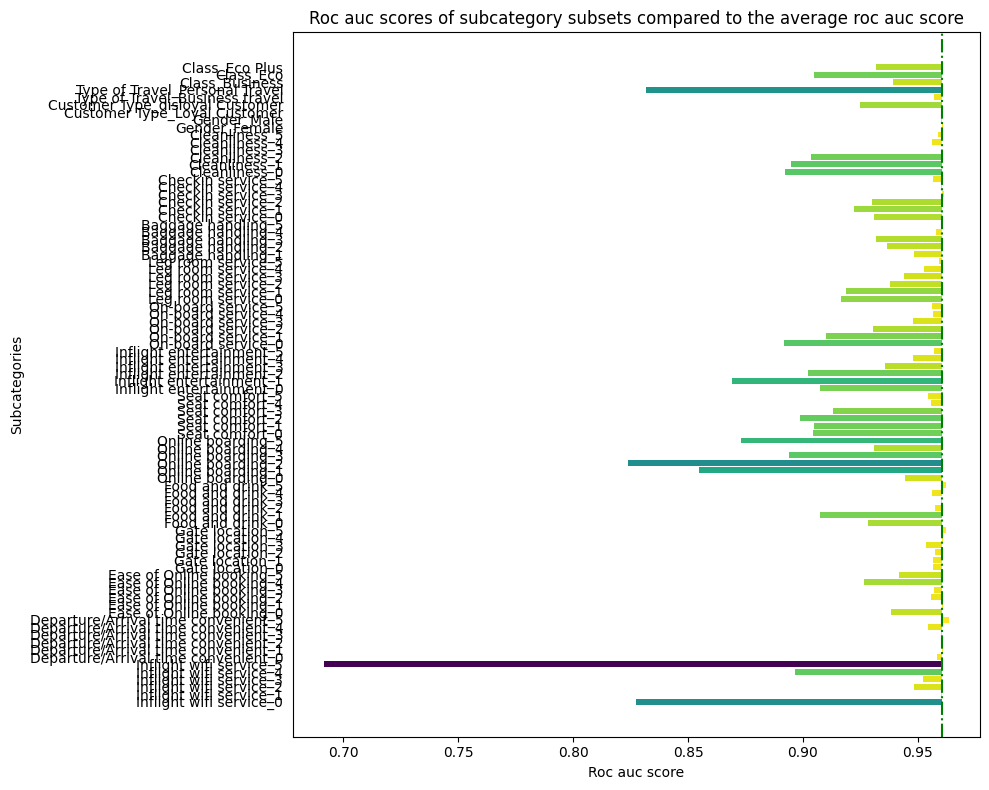

In [24]:
## Show roc auc scores of subcategory subsets

subcats = []
subcat_roc_auc_scores  = []
for cat in orig_cat_columns:
    for subcat in np.sort([cat for cat in trainval[cat].unique() if cat not in [np.nan]]):
        if trainval[target][trainval[cat] == subcat].nunique() == 2:
            subcats.append(cat+'_'+str(subcat))
            val_filtered = val_preds[target][trainval[cat] == subcat]
            val_labels_filtered = val_preds['pred_score'][trainval[cat] == subcat]
            subcat_roc_auc_scores.append(roc_auc_score(val_filtered, val_labels_filtered))

# Create bar chart
fig1, ax1 = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap('viridis')
rescale = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))
normalized_values = rescale(subcat_roc_auc_scores)
ax1.barh(subcats, np.array(subcat_roc_auc_scores)-overall_oof_score, color=cmap(normalized_values), left=overall_oof_score)
plt.title(f'Roc auc scores of subcategory subsets compared to the average roc auc score')
plt.xlabel('Roc auc score')
plt.ylabel('Subcategories')
ax1.axvline(x=overall_oof_score, color='green', linestyle='-.')
plt.tight_layout()
ax1.tick_params(left=False, bottom=True)

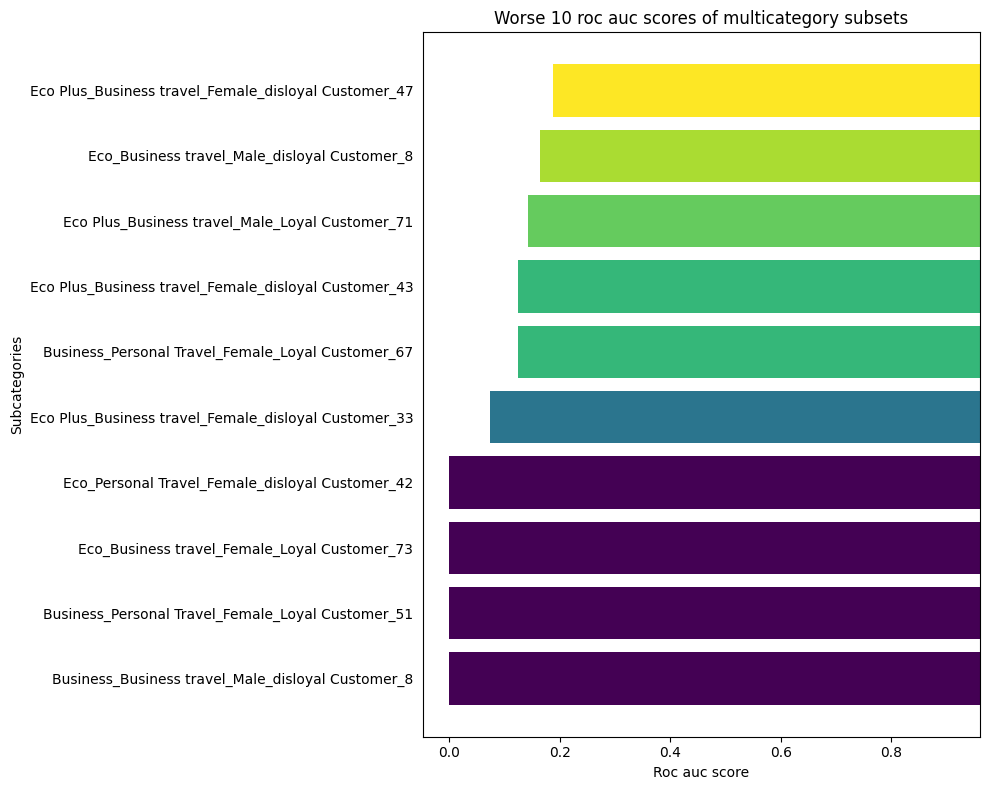

In [25]:
## Show worse roc auc scores of multicategory subsets

if not TUNING:
    multicats = []
    multicat_roc_auc_scores = []
    for multicat in trainval['multicat'].unique():
        if trainval[target][trainval['multicat'] == multicat].nunique() == 2:
            multicats.append(multicat)
            val_filtered = val_preds[target][trainval['multicat'] == multicat]
            val_labels_filtered = val_preds['pred_score'][trainval['multicat'] == multicat]
            multicat_roc_auc_scores.append(roc_auc_score(val_filtered, val_labels_filtered))
    multicats = multicat_encoder.inverse_transform(multicats)
    sorted_multicat_roc_auc_scores, sorted_multicats = zip(*sorted(zip(multicat_roc_auc_scores, multicats), reverse=False))
    
    # Create bar chart
    fig2, ax2 = plt.subplots(figsize=(10, 8))
    n_top = 10
    cmap = plt.get_cmap('viridis')
    rescale = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x))
    normalized_values = rescale(sorted_multicat_roc_auc_scores[:n_top])
    ax2.barh(sorted_multicats[:n_top], np.array(sorted_multicat_roc_auc_scores[:n_top])-overall_oof_score,
             color=cmap(normalized_values), left=overall_oof_score)
    plt.title(f'Worse {n_top} roc auc scores of multicategory subsets')
    plt.xlabel('Roc auc score')
    plt.ylabel('Subcategories')
    plt.tight_layout()
    ax2.tick_params(left=False, bottom=True)

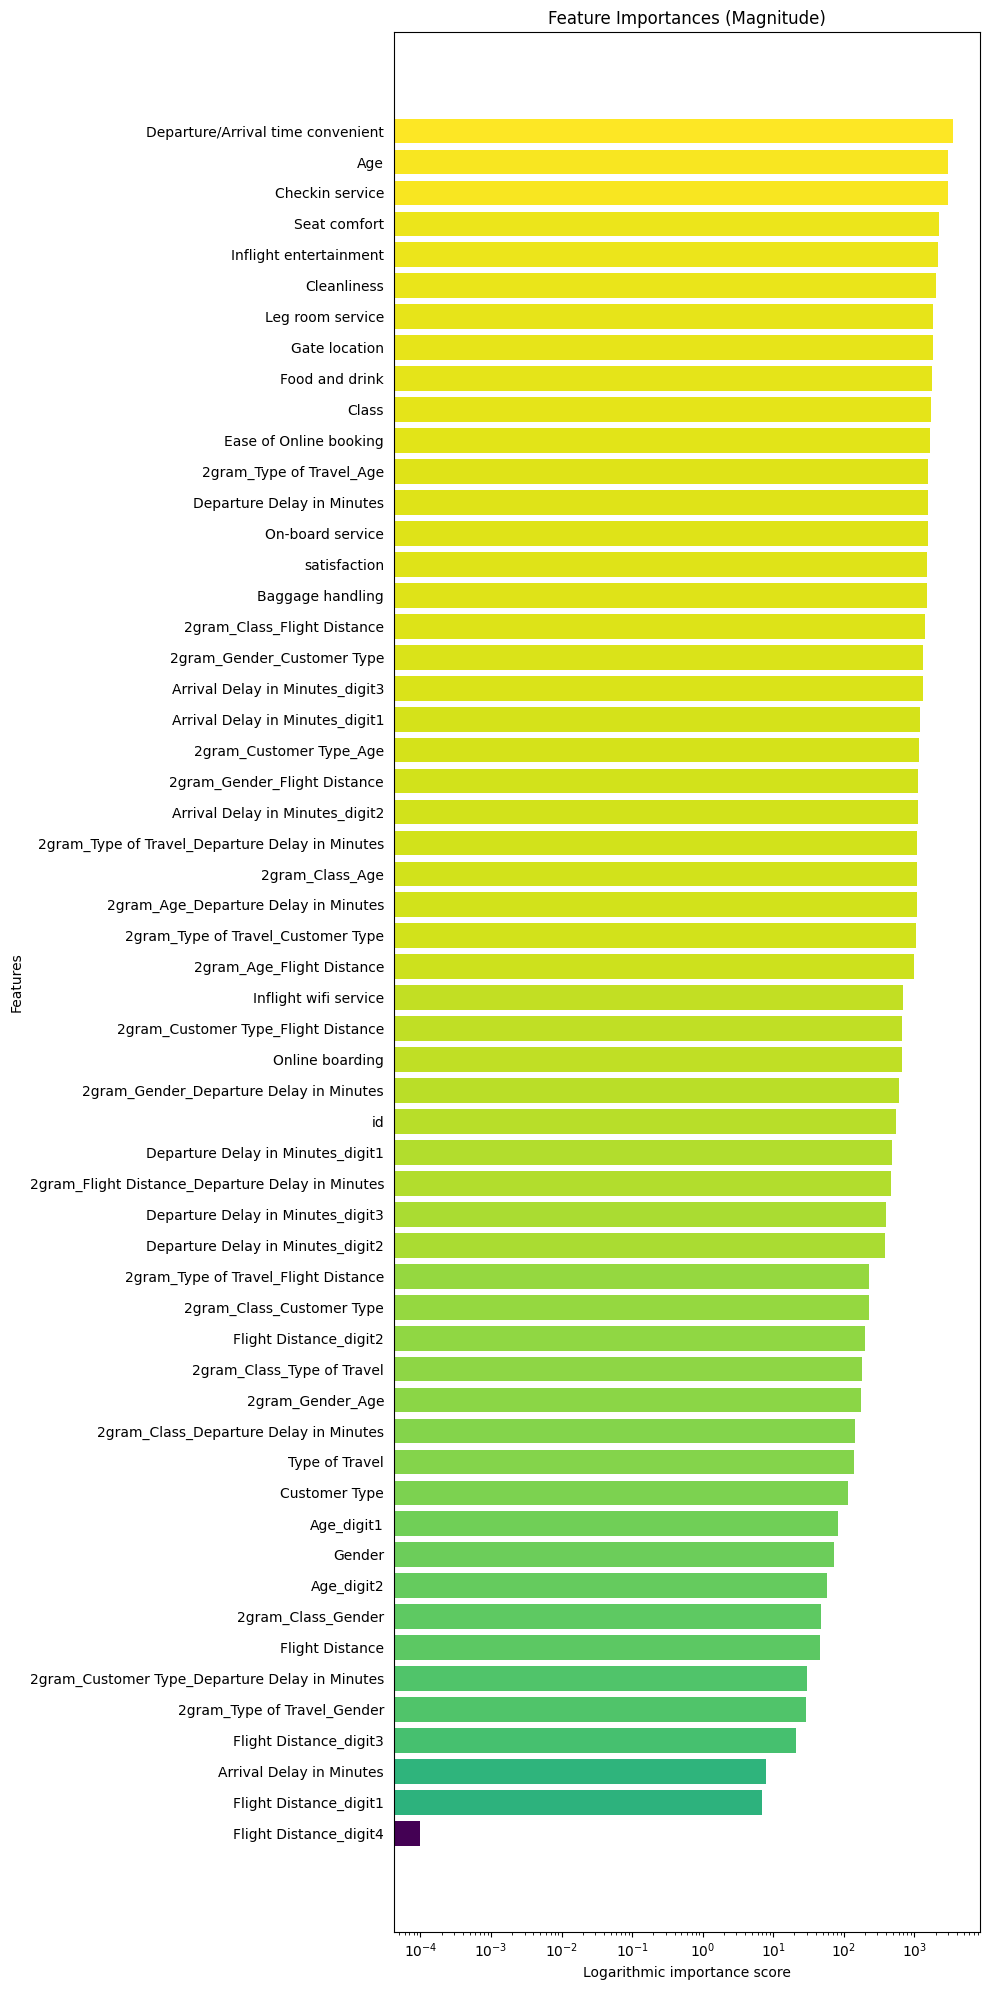

In [26]:
## Show feature importances

if est_id in [5, 8, 9] and not TUNING:
    # Sort feature names and their importances
    categories = X_train.columns
    values = globals()[f'model{FOLDS}_{EstimatorStr[est_id]}'][-1].feature_importances_+1e-4
    sorted_values, sorted_categories = zip(*sorted(zip(values,categories), reverse=False))
    
    # Plot feature importances
    fig3, ax3 = plt.subplots(figsize=(10, 20))
    normalized_values = rescale(np.log(sorted_values))
    ax3.barh(sorted_categories, sorted_values, color=cmap(normalized_values), log=True)
    plt.title(f'Feature Importances (Magnitude)')
    plt.xlabel('Logarithmic importance score')
    plt.ylabel('Features')
    plt.tight_layout()
    ax3.tick_params(left=False, bottom=True)

# 8. Submission

In [27]:
## Test prediction & submission 

submission_df = test[['id']].copy()

# Take the mean value of prediction over all estimators and folds
submission_df[target] = test_blend

# Write dataframe to .csv file
submission_df.to_csv('submission.csv', index=False)
print('✅ submission.csv saved!')
submission_df

✅ submission.csv saved!


,id,satisfaction
0,699635,0.302033
1,699636,0.829074
2,699637,0.948542
3,699638,0.083631
4,699639,0.043606
...,...,...
299839,999474,0.057295
299840,999475,0.044274
299841,999476,0.316368
299842,999477,0.023197
